# Advanced Portfolio Optimization Methods

This notebook provides a comprehensive analysis of portfolio optimization methods, from classical approaches to advanced techniques based on the work of Marcos Lopez de Prado.

## Concepts Covered in This Notebook

### Part 1: Portfolio Construction Methods
1. **Mean-Variance Optimization**
   - Maximum Sharpe Ratio Portfolio
   - Minimum Variance Portfolio
   - Efficient Frontier Analysis

2. **Risk Parity (ERC)**
   - Equal risk contribution from each asset
   - Risk contribution analysis
   - Risk budgeting applications

3. **Nested Clustered Optimization (NCO)**
   - Two-level optimization (within/between clusters)
   - Cluster-based asset grouping
   - Large portfolio stability

4. **Hierarchical Risk Parity (HRP)**
   - Hierarchical clustering-based allocation
   - Inverse variance weighting
   - Avoids covariance matrix inversion

5. **Return-Enhanced Hierarchical Risk Parity (RE-HRP)**
   - Information Ratio-based allocation
   - Return-aware clustering
   - Benchmark-relative performance

6. **Equal-Weighted Portfolio** (baseline comparison)

### Part 2: Leverage and Advanced Strategies
7. **Leveraged Portfolios (1.5x)**
   - Leveraged Risk Parity
   - Leveraged HRP, NCO, Mean-Variance, RE-HRP
   - Asset class allocation analysis with leverage
   - Risk amplification analysis

### Part 3: Performance Analysis and Statistics
8. **Comprehensive Risk-Return Analysis**
   - Expected Return (annualized)
   - Volatility (annualized)
   - Sharpe Ratio
   - Information Ratio (for RE-HRP)
   - Maximum Drawdown
   - Method-by-method comparison tables
   - Performance ranking
   - Risk-adjusted return analysis

### Part 4: Out-of-Sample Validation
9. **Out-of-Sample Volatility Forecasting**
    - Train/test split (70/30 time-based)
    - Forecasted vs realized volatility
    - Forecast error and accuracy metrics
    - Volatility ratio analysis
    - Volatility forecast accuracy visualizations

10. **Out-of-Sample Testing Framework**
    - Training phase: Fit optimizers on training data
    - Testing phase: Evaluate on unseen test data
    - Train vs test performance comparison
    - Leveraged portfolio out-of-sample testing
    - Monte Carlo Simulation (MCS) for value-weighted approaches
    - Cumulative returns comparison
    - Risk-return scatter (train vs test)
    - Maximum drawdown comparison

### Part 5: Mathematical Verification and Production Readiness
11. **Mathematical Correctness Verification**
    - Risk contribution formula verification
    - Weight constraint verification
    - Portfolio variance formula verification
    - HRP inverse variance weighting verification
    - NCO cluster structure verification
    - Leverage constraint verification


### Data and Portfolio
- **Portfolio**: 12 ETF Multi-Asset Portfolio
  - Crypto: BTC-USD, ETH-USD, SOL-USD
  - Stocks: SPY, QQQ, IWM
  - Bonds: TLT, AGG, LQD
  - Commodities: GLD, SLV, DBA
- **Data Period**: 2010-01-01 to present
- **Analysis Focus**: Risk-adjusted returns, volatility forecasting, out-of-sample performance



In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.optimize import minimize
from tabulate import tabulate
import matplotlib.pyplot as plt

from portfolios.portfolio_src import (
    HierarchicalRiskParity,
    ReturnEnhancedHRP,
    RiskParity,
    NestedClusteredOptimization
)
from scipy.optimize import minimize
from portfolios.utilities.portfolio_utilties import (
    portfolio_expected_return, 
    portfolio_volatility,
    plot_efficient_frontier,
    weighted_portfolio_returns
)


# Portfolio tickers: Asset Class ETFs for proper portfolio allocation
# Using actual asset classes (ETFs) instead of individual stocks for better mathematical precision
tickers = [

    # crypto
    "BTC-USD",
    "ETH-USD",
    "SOL-USD",
    # Stocks (Equity Asset Class)
    "SPY",    # S&P 500 - Large cap US stocks
    "QQQ",    # Nasdaq 100 - Tech-heavy US stocks
    "IWM",    # Russell 2000 - Small cap US stocks
    
    # Bonds (Fixed Income Asset Class)
    "TLT",    # 20+ Year Treasury - Long-term government bonds
    "AGG",    # Aggregate Bond - Total bond market
    "LQD",    # Corporate Bond - Investment grade corporate bonds
    
    # Commodities (Alternative Asset Class)
    "GLD",    # Gold - Precious metals
    "SLV",    # Silver - Precious metals
    "DBA",    # Agriculture - Commodities basket
]

print("Portfolio Asset Classes:")
print("=" * 60)
print("Crypto (U.S. Crypto Strategic Reserve):     BTC-USD, ETH-USD, SOL-USD")
print("Stocks (Equity):                            SPY, QQQ, IWM")
print("Bonds (Fixed Income):                       TLT, AGG, LQD")
print("Commodities:                                GLD, SLV, DBA")
print("=" * 60)

df = yf.download(tickers, start='2010-01-01')
ret_df = df.xs("Close", axis=1, level='Price').pct_change().dropna()

print(f"\nData loaded: {len(ret_df)} days from {ret_df.index[0].date()} to {ret_df.index[-1].date()}")
print(f"Assets: {len(ret_df.columns)} asset class ETFs")# Import portfolio optimizers
 

Portfolio Asset Classes:
Crypto (U.S. Crypto Strategic Reserve):     BTC-USD, ETH-USD, SOL-USD
Stocks (Equity):                            SPY, QQQ, IWM
Bonds (Fixed Income):                       TLT, AGG, LQD
Commodities:                                GLD, SLV, DBA


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_41916/3657081537.py:55: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start='2010-01-01')
[*********************100%***********************]  12 of 12 completed
/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_41916/3657081537.py:56: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_df = df.xs("Close", axis=1, level='Price').pct_change().dropna()



Data loaded: 2088 days from 2020-04-11 to 2025-12-28
Assets: 12 asset class ETFs


In [7]:
# Mean-Variance Optimization
# Find maximum Sharpe ratio portfolio and minimum variance portfolio

# Calculate expected returns and covariance matrix
expected_returns = ret_df.mean().values
cov_matrix = ret_df.cov().values
risk_free_rate = 0.02 / 252  # Daily risk-free rate (annual 2%)

# Objective function: negative Sharpe ratio (for minimization)
def negative_sharpe(weights):
    """Minimize negative Sharpe ratio to maximize Sharpe ratio"""
    port_return = expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    if port_vol == 0:
        return 1e10  # Avoid division by zero
    sharpe = (port_return - risk_free_rate) / port_vol
    return -sharpe  # Negative for minimization

# Constraints: weights sum to 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

# Bounds: long-only (0 to 1)
bounds = tuple((0, 1) for _ in range(len(ret_df.columns)))

# Initial guess: equal weights
initial_weights = np.ones(len(ret_df.columns)) / len(ret_df.columns)

# Optimize for maximum Sharpe ratio
mv_result = minimize(negative_sharpe, initial_weights, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
mv_weights = mv_result.x

# Also find minimum variance portfolio
def portfolio_variance(weights):
    """Minimize portfolio variance"""
    return weights.T @ cov_matrix @ weights

mv_minvar_result = minimize(portfolio_variance, initial_weights, method='SLSQP',
                            bounds=bounds, constraints=constraints)
mv_minvar_weights = mv_minvar_result.x

# Display results
print("Mean-Variance Optimization Results:")
print("=" * 60)
print("\nMaximum Sharpe Ratio Portfolio:")
for asset, weight in zip(ret_df.columns, mv_weights):
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")
print(f"\nSum of weights: {mv_weights.sum():.6f}")

mv_return = portfolio_expected_return(ret_df, mv_weights) * 252
mv_vol = portfolio_volatility(ret_df, mv_weights) * np.sqrt(252)
mv_sharpe = (mv_return - 0.02) / mv_vol

print(f"\nPerformance (annualized):")
print(f"  Expected Return: {mv_return:.4%}")
print(f"  Volatility: {mv_vol:.4%}")
print(f"  Sharpe Ratio: {mv_sharpe:.4f}")

print("\n" + "-" * 60)
print("\nMinimum Variance Portfolio:")
for asset, weight in zip(ret_df.columns, mv_minvar_weights):
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")
print(f"\nSum of weights: {mv_minvar_weights.sum():.6f}")

mv_minvar_return = portfolio_expected_return(ret_df, mv_minvar_weights) * 252
mv_minvar_vol = portfolio_volatility(ret_df, mv_minvar_weights) * np.sqrt(252)
mv_minvar_sharpe = (mv_minvar_return - 0.02) / mv_minvar_vol

print(f"\nPerformance (annualized):")
print(f"  Expected Return: {mv_minvar_return:.4%}")
print(f"  Volatility: {mv_minvar_vol:.4%}")
print(f"  Sharpe Ratio: {mv_minvar_sharpe:.4f}")

# Portfolio construction complete - weights and performance metrics displayed above

Mean-Variance Optimization Results:

Maximum Sharpe Ratio Portfolio:
  AGG: 0.0000 (0.00%)
  BTC-USD: 0.0331 (3.31%)
  DBA: 0.3218 (32.18%)
  ETH-USD: 0.0000 (0.00%)
  GLD: 0.3866 (38.66%)
  IWM: 0.0000 (0.00%)
  LQD: 0.0000 (0.00%)
  QQQ: 0.0003 (0.03%)
  SLV: 0.0088 (0.88%)
  SOL-USD: 0.0668 (6.68%)
  SPY: 0.1826 (18.26%)
  TLT: 0.0000 (0.00%)

Sum of weights: 1.000000

Performance (annualized):
  Expected Return: 19.3204%
  Volatility: 12.1001%
  Sharpe Ratio: 1.4314

------------------------------------------------------------

Minimum Variance Portfolio:
  AGG: 0.1065 (10.65%)
  BTC-USD: 0.0580 (5.80%)
  DBA: 0.1051 (10.51%)
  ETH-USD: 0.0370 (3.70%)
  GLD: 0.1030 (10.30%)
  IWM: 0.0940 (9.40%)
  LQD: 0.1048 (10.48%)
  QQQ: 0.0940 (9.40%)
  SLV: 0.0946 (9.46%)
  SOL-USD: 0.0000 (0.00%)
  SPY: 0.0972 (9.72%)
  TLT: 0.1057 (10.57%)

Sum of weights: 1.000000

Performance (annualized):
  Expected Return: 12.4034%
  Volatility: 10.6519%
  Sharpe Ratio: 0.9767


# Risk Parity (ERC)



In [8]:
# Fit Risk Parity optimizer
rp = RiskParity()
rp.fit(ret_df)

# Get portfolio weights
rp_weights = rp.predict()
rp_weights_dict = rp.get_weights_dict()

print("Risk Parity Portfolio Weights:")
for asset, weight in rp_weights_dict.items():
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")

print(f"\nSum of weights: {sum(rp_weights_dict.values()):.6f}")


# Check risk contributions (should be approximately equal)
risk_contribs = rp.get_risk_contribution_percentages()

print("Risk Contribution Percentages (should be approximately equal):")
for asset, pct in risk_contribs.items():
    print(f"  {asset}: {pct:.2f}%")

print(f"\nTarget: {100/len(ret_df.columns):.2f}% per asset (equal risk contribution)")

# Calculate Risk Parity portfolio performance
rp_return, rp_vol, rp_sharpe = rp.portfolio_performance(risk_free_rate=0.02)

print("Risk Parity Portfolio Performance:")
print(f"Expected Return (annualized): {rp_return:.4%}")
print(f"Volatility (annualized): {rp_vol:.4%}")
print(f"Sharpe Ratio (annualized): {rp_sharpe:.4f}")


# Portfolio construction complete - weights and performance metrics displayed above


Risk Parity Portfolio Weights:
  AGG: 0.0999 (9.99%)
  BTC-USD: 0.0495 (4.95%)
  DBA: 0.1008 (10.08%)
  ETH-USD: 0.0152 (1.52%)
  GLD: 0.1031 (10.31%)
  IWM: 0.1018 (10.18%)
  LQD: 0.1013 (10.13%)
  QQQ: 0.1018 (10.18%)
  SLV: 0.1039 (10.39%)
  SOL-USD: 0.0182 (1.82%)
  SPY: 0.1025 (10.25%)
  TLT: 0.1020 (10.20%)

Sum of weights: 1.000000
Risk Contribution Percentages (should be approximately equal):
  AGG: 1.90%
  BTC-USD: 14.29%
  DBA: 3.21%
  ETH-USD: 5.75%
  GLD: 6.28%
  IWM: 13.26%
  LQD: 3.59%
  QQQ: 13.29%
  SLV: 15.27%
  SOL-USD: 9.35%
  SPY: 10.42%
  TLT: 3.42%

Target: 8.33% per asset (equal risk contribution)
Risk Parity Portfolio Performance:
Expected Return (annualized): 13.2887%
Volatility (annualized): 10.7529%
Sharpe Ratio (annualized): 1.0498


# Nested Clustering Optimization (NCO)  



In [9]:
# Fit NCO optimizer
# Using risk parity within clusters for more stable results
nco = NestedClusteredOptimization(
    n_clusters=4,  # Cluster into 4 groups
    within_cluster_method='risk_parity'
)
nco.fit(ret_df)

# Get portfolio weights
nco_weights = nco.predict()
nco_weights_dict = nco.get_weights_dict()

print("NCO Portfolio Weights:")
for asset, weight in nco_weights_dict.items():
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")

print(f"\nSum of weights: {sum(nco_weights_dict.values()):.6f}")

# View cluster assignments
cluster_assignments = nco.get_cluster_assignments()

print("Cluster Assignments:")
for cluster_id in sorted(set(cluster_assignments.values())):
    assets_in_cluster = [asset for asset, cid in cluster_assignments.items() if cid == cluster_id]
    print(f"  Cluster {cluster_id}: {', '.join(assets_in_cluster)}")

# Calculate NCO portfolio performance
nco_return, nco_vol, nco_sharpe = nco.portfolio_performance(risk_free_rate=0.02)

print("NCO Portfolio Performance:")
print(f"Expected Return (annualized): {nco_return:.4%}")
print(f"Volatility (annualized): {nco_vol:.4%}")
print(f"Sharpe Ratio (annualized): {nco_sharpe:.4f}")


# Portfolio construction complete - weights and performance metrics displayed above

NCO Portfolio Weights:
  AGG: 0.0000 (0.00%)
  BTC-USD: 0.0000 (0.00%)
  DBA: 0.0000 (0.00%)
  ETH-USD: 0.0000 (0.00%)
  GLD: 0.0000 (0.00%)
  IWM: 0.1814 (18.14%)
  LQD: 0.0000 (0.00%)
  QQQ: 0.0000 (0.00%)
  SLV: 0.6134 (61.34%)
  SOL-USD: 0.2051 (20.51%)
  SPY: 0.0000 (0.00%)
  TLT: 0.0000 (0.00%)

Sum of weights: 1.000000
Cluster Assignments:
  Cluster 1: AGG, LQD, TLT
  Cluster 2: DBA, GLD, SLV
  Cluster 3: IWM, QQQ, SPY
  Cluster 4: BTC-USD, ETH-USD, SOL-USD
NCO Portfolio Performance:
Expected Return (annualized): 38.6157%
Volatility (annualized): 29.3489%
Sharpe Ratio (annualized): 1.2476


## Hierarchical Risk Parity (HRP)


HRP Portfolio Weights:
  AGG: 0.5512 (55.12%)
  BTC-USD: 0.0004 (0.04%)
  DBA: 0.0606 (6.06%)
  ETH-USD: 0.0003 (0.03%)
  GLD: 0.0332 (3.32%)
  IWM: 0.0064 (0.64%)
  LQD: 0.2048 (20.48%)
  QQQ: 0.0038 (0.38%)
  SLV: 0.0068 (0.68%)
  SOL-USD: 0.0001 (0.01%)
  SPY: 0.0039 (0.39%)
  TLT: 0.1287 (12.87%)

Sum of weights: 1.000000
HRP Portfolio Performance:
Expected Return (annualized): 0.9818%
Volatility (annualized): 5.8503%
Sharpe Ratio (annualized): -0.1741


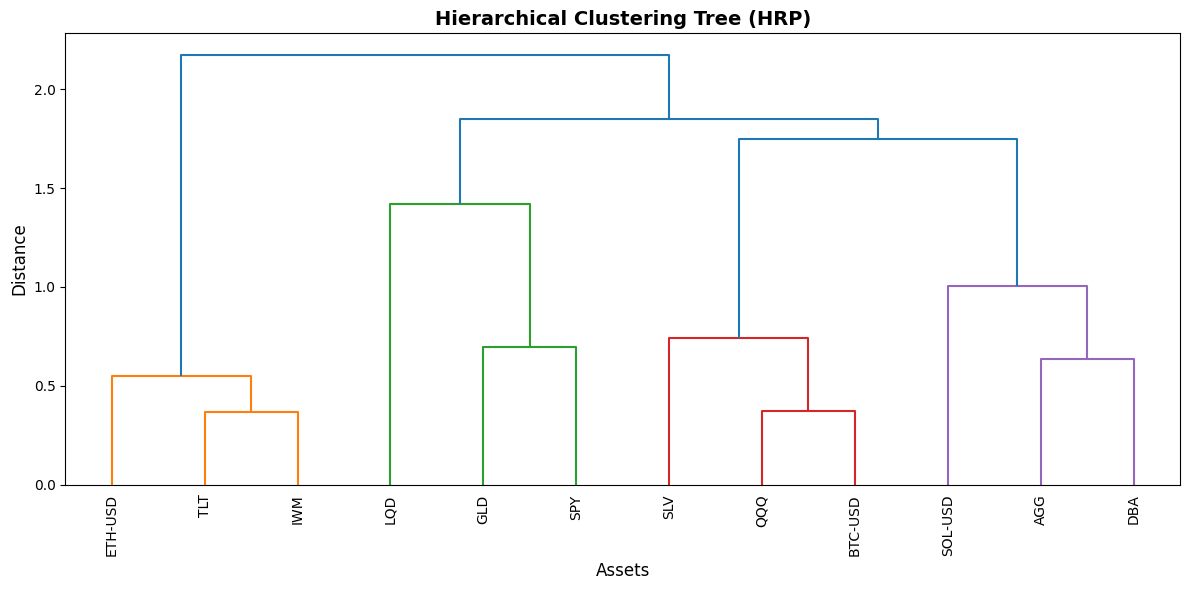

In [10]:
# Fit HRP optimizer
hrp = HierarchicalRiskParity(linkage_method='ward')
hrp.fit(ret_df)

# Get portfolio weights
hrp_weights = hrp.predict()
hrp_weights_dict = hrp.get_weights_dict()

print("HRP Portfolio Weights:")
for asset, weight in hrp_weights_dict.items():
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")

print(f"\nSum of weights: {sum(hrp_weights_dict.values()):.6f}")

# Calculate HRP portfolio performance
hrp_return, hrp_vol, hrp_sharpe = hrp.portfolio_performance(risk_free_rate=0.02)

print("HRP Portfolio Performance:")
print(f"Expected Return (annualized): {hrp_return:.4%}")
print(f"Volatility (annualized): {hrp_vol:.4%}")
print(f"Sharpe Ratio (annualized): {hrp_sharpe:.4f}")

# Visualize hierarchical clustering tree
fig, ax = hrp.plot_dendrogram()
plt.show()

## Return-Enhanced Hierarchical Risk Parity (RE-HRP)

RE-HRP extends HRP by incorporating return information through risk-adjusted return maximization (default: Information Ratio, with Sharpe Ratio and Sortino Ratio as options). It preserves HRP's clustering structure but allocates capital based on risk-adjusted returns rather than pure risk parity.

**Key Feature**: Information Ratio (default) compares sub-portfolios against an equal-weighted benchmark, favoring clusters that generate excess returns relative to the benchmark. This approach:
1. Preserves HRP's correlation-based clustering structure
2. Favors return characteristics within each cluster
3. Avoids over-weighting low-volatility assets with modest returns (like TLT bonds)
4. Leverages covariance matrix information to identify return clusters

**Information Ratio Formula**: $IR = \frac{E[R_{portfolio}] - E[R_{benchmark}]}{\sigma_{excess}}$ where $\sigma_{excess}$ is the tracking error (volatility of excess returns).

**Thresholds and Constraints (Prevent Low-Return Asset Over-weighting):**
- **Minimum Return Threshold**: Only clusters with return ≥ threshold are considered (default: benchmark return)
- **Tracking Error Floor**: Minimum tracking error (1% annualized) prevents tiny denominators from inflating IR
- **Fallback Logic**: If thresholds aren't met, falls back to return-based allocation
- These constraints prevent low-return, low-volatility assets (like TLT) from getting excessive weights

RE-HRP: Information Ratio Allocation
Benchmark: Equal-weighted portfolio of 12 assets
Allocation Metric: Information Ratio
Formula: α = IR_right / (IR_left + IR_right)
Information Ratio = (E[R_portfolio] - E[R_benchmark]) / Tracking_Error
assets if the benchmark performs well. Consider using 'sharpe' instead.
  Threshold check: Right meets (Left single asset (13.0114%), Right single asset (110.4976%), threshold=24.2082%)
  Cluster split: 1 assets left, 1 assets right
  IR_left: 0.0010, IR_right: 1.0000
  Allocation α: 0.9000 (10.0% left, 90.0% right)
  Threshold check: Both meet (Left cluster (100.7490%), Right single asset (42.3950%), threshold=24.2082%)
  Cluster split: 2 assets left, 1 assets right
  IR_left: 0.9888, IR_right: 0.5174
  Allocation α: 0.3435 (65.7% left, 34.3% right)
  Threshold check: Both meet (Left cluster (80.7049%), Right single asset (56.4750%), threshold=24.2082%)
  Cluster split: 3 assets left, 1 assets right
  IR_left: 1.0337, IR_right: 0.6417
  Allocation α:

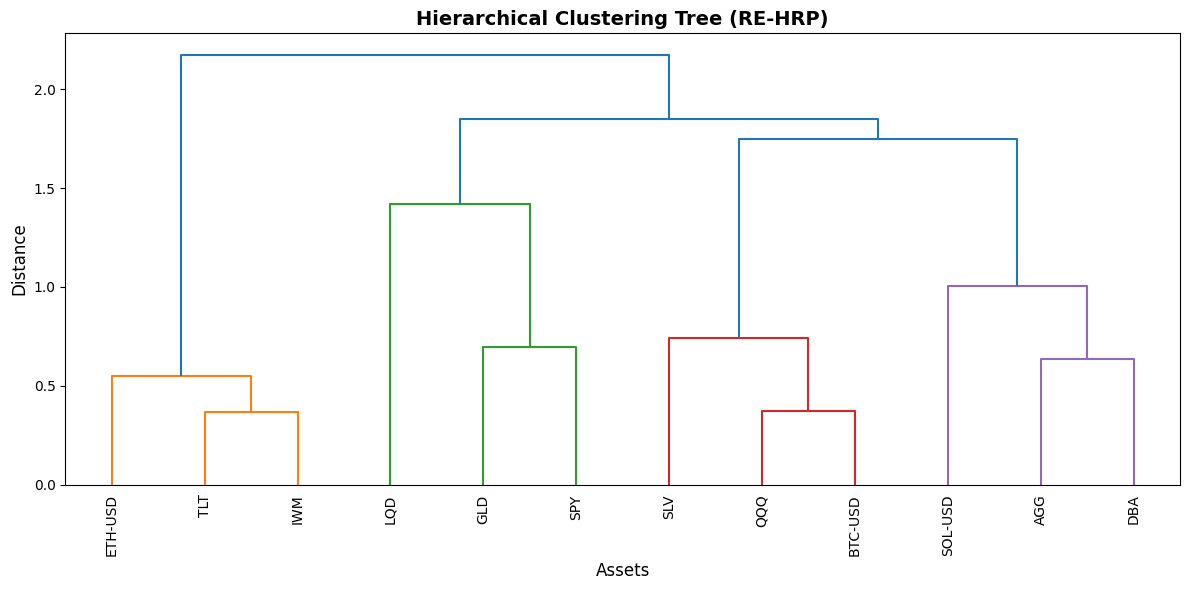

In [11]:
#----- RE-HRP -----
# Fit RE-HRP optimizer
# Default: Information Ratio (favors return clusters vs equal-weighted benchmark)
# Options: Use allocation_metric='sharpe' for Sharpe Ratio or 'sortino' for Sortino Ratio
# verbose=True shows detailed Information Ratio calculations during allocation
# min_return_threshold: None = use benchmark return as threshold (prevents low-return asset over-weighting)
# min_tracking_error: 1% floor prevents tiny denominators from inflating IR
re_hrp = ReturnEnhancedHRP(
    linkage_method='ward', 
    risk_free_rate=0.02, 
    allocation_metric='information_ratio',  # Default
    verbose=True,  # Show Information Ratio calculations
    min_return_threshold=None,  # None = use benchmark return as threshold
    min_tracking_error=0.01  # 1% annualized floor to prevent IR inflation
)
re_hrp.fit(ret_df)

# Get portfolio weights
re_hrp_weights = re_hrp.predict()
re_hrp_weights_dict = re_hrp.get_weights_dict()

print("RE-HRP Portfolio Weights:")
for asset, weight in re_hrp_weights_dict.items():
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")

print(f"\nSum of weights: {sum(re_hrp_weights_dict.values()):.6f}")
re_hrp_return, re_hrp_vol, re_hrp_sharpe = re_hrp.portfolio_performance(risk_free_rate=0.02)

# Calculate RE-HRP portfolio performance
re_hrp_return, re_hrp_vol, re_hrp_sharpe = re_hrp.portfolio_performance(risk_free_rate=0.02)

# Calculate Information Ratio vs equal-weighted benchmark
from portfolios.utilities.portfolio_utilties import weighted_portfolio_returns
equal_weights = np.ones(len(ret_df.columns)) / len(ret_df.columns)
benchmark_returns = weighted_portfolio_returns(ret_df, equal_weights)
re_hrp_portfolio_returns = weighted_portfolio_returns(ret_df, re_hrp_weights)
excess_returns = re_hrp_portfolio_returns - benchmark_returns
tracking_error = excess_returns.std() * np.sqrt(252)
info_ratio = (re_hrp_return - (benchmark_returns.mean() * 252)) / tracking_error if tracking_error > 0 else 0

print("RE-HRP Portfolio Performance:")
print(f"Expected Return (annualized): {re_hrp_return:.4%}")
print(f"Volatility (annualized): {re_hrp_vol:.4%}")
print(f"Sharpe Ratio (annualized): {re_hrp_sharpe:.4f}")
print(f"Information Ratio (vs equal-weighted benchmark): {info_ratio:.4f}")

print(f"\nBenchmark Comparison (Equal-Weighted):")
benchmark_return = benchmark_returns.mean() * 252
benchmark_vol = benchmark_returns.std() * np.sqrt(252)
print(f"  Benchmark Return (annualized): {benchmark_return:.4%}")
print(f"  Benchmark Volatility (annualized): {benchmark_vol:.4%}")
print(f"  Excess Return: {re_hrp_return - benchmark_return:.4%}")
print(f"  Tracking Error: {tracking_error:.4%}")

print(f"\nInformation Ratio Interpretation:")
print(f"  IR = (Portfolio Return - Benchmark Return) / Tracking Error")
print(f"  IR > 0: Portfolio outperforms benchmark on risk-adjusted basis")
print(f"  IR = {info_ratio:.4f}: {'Outperforms' if info_ratio > 0 else 'Underperforms'} benchmark")

# Verify clustering is preserved (same as HRP)
print(f"\nClustering Verification:")
print(f"  RE-HRP tree order matches HRP: {np.array_equal(re_hrp.tree_order_, hrp.tree_order_)}")
print(f"  RE-HRP linkage matches HRP: {np.array_equal(re_hrp.linkage_matrix_, hrp.linkage_matrix_)}")

# Visualize hierarchical clustering tree (same as HRP)
fig, ax = re_hrp.plot_dendrogram()
plt.show()

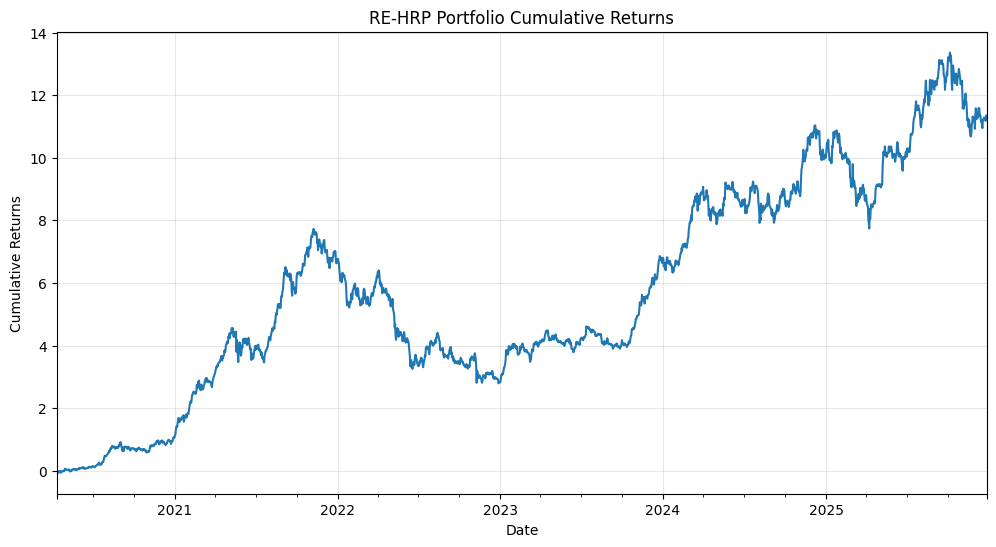

In [12]:
# Calculate RE-HRP portfolio returns
re_hrp_portfolio_returns = weighted_portfolio_returns(ret_df, re_hrp_weights)
re_hrp_cumulative = (1 + re_hrp_portfolio_returns).cumprod() - 1

re_hrp_cumulative.plot(title="RE-HRP Portfolio Cumulative Returns", figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.grid(True, alpha=0.3)
plt.show()

## Part 2: Leverage Portfolios (1.5x Leverage)

Leverage allows investors to amplify their exposure to assets by borrowing capital. A 1.5x leveraged portfolio means that for every $1 of capital, the investor controls $1.50 worth of assets.

**Why Leverage for Small Funds:**
- Amplifies returns (and risks) proportionally
- Allows access to more opportunities with limited capital
- Can improve risk-adjusted returns if used judiciously
- Enables more aggressive positioning

**Risk Amplification:**
- Portfolio volatility scales with leverage factor ($\sigma_{p_leveraged}$ ≈ $leverage × \sigma_{p}$)
- Both returns and risks are amplified
- Requires careful risk management and monitoring
- Margin requirements and borrowing costs must be considered

**Implementation:**
- For Risk Parity: Built-in `leverage` parameter
- For HRP and NCO: Scale weights after optimization (multiply by leverage factor)
- For Mean-Variance: Scale weights after optimization
- For RE-HRP: Scale weights after optimization


In [13]:
# Leveraged Portfolios (1.5x Leverage)
# This section creates leveraged portfolios using all optimization methods.
# These same portfolios will be analyzed below by asset class composition.

# Leveraged Risk Parity (1.5x) - built-in support
rp_leveraged = RiskParity(leverage=1.5)
rp_leveraged.fit(ret_df)
rp_lev_weights = rp_leveraged.predict()

# Leveraged HRP (1.5x) - scale weights after optimization
hrp_base = HierarchicalRiskParity()
hrp_base.fit(ret_df)
hrp_lev_weights = hrp_base.predict() * 1.5

# Leveraged NCO (1.5x) - scale weights after optimization
nco_base = NestedClusteredOptimization()
nco_base.fit(ret_df)
nco_lev_weights = nco_base.predict() * 1.5

# Leveraged Mean-Variance (1.5x) - scale weights after optimization
mv_lev_weights = mv_weights * 1.5
mv_minvar_lev_weights = mv_minvar_weights * 1.5

# Leveraged RE-HRP (1.5x) - scale weights after optimization
re_hrp_lev_weights = re_hrp_weights * 1.5

# Verify leverage: all should sum to 1.5
print("Leveraged Portfolios (1.5x):")
print("=" * 60)
print(f"Risk Parity Leveraged sum: {rp_lev_weights.sum():.6f} (target: 1.5)")
print(f"HRP Leveraged sum: {hrp_lev_weights.sum():.6f} (target: 1.5)")
print(f"NCO Leveraged sum: {nco_lev_weights.sum():.6f} (target: 1.5)")
print(f"Mean-Variance (Max Sharpe) Leveraged sum: {mv_lev_weights.sum():.6f} (target: 1.5)")
print(f"Mean-Variance (Min Var) Leveraged sum: {mv_minvar_lev_weights.sum():.6f} (target: 1.5)")
print(f"RE-HRP Leveraged sum: {re_hrp_lev_weights.sum():.6f} (target: 1.5)")

# Calculate performance metrics for leveraged portfolios
from portfolios.utilities.portfolio_utilties import portfolio_expected_return, portfolio_volatility

rp_lev_return = portfolio_expected_return(ret_df, rp_lev_weights) * 252
rp_lev_vol = portfolio_volatility(ret_df, rp_lev_weights) * np.sqrt(252)
rp_lev_sharpe = (rp_lev_return - 0.02) / rp_lev_vol if rp_lev_vol > 0 else 0

hrp_lev_return = portfolio_expected_return(ret_df, hrp_lev_weights) * 252
hrp_lev_vol = portfolio_volatility(ret_df, hrp_lev_weights) * np.sqrt(252)
hrp_lev_sharpe = (hrp_lev_return - 0.02) / hrp_lev_vol if hrp_lev_vol > 0 else 0

nco_lev_return = portfolio_expected_return(ret_df, nco_lev_weights) * 252
nco_lev_vol = portfolio_volatility(ret_df, nco_lev_weights) * np.sqrt(252)
nco_lev_sharpe = (nco_lev_return - 0.02) / nco_lev_vol if nco_lev_vol > 0 else 0

mv_lev_return = portfolio_expected_return(ret_df, mv_lev_weights) * 252
mv_lev_vol = portfolio_volatility(ret_df, mv_lev_weights) * np.sqrt(252)
mv_lev_sharpe = (mv_lev_return - 0.02) / mv_lev_vol if mv_lev_vol > 0 else 0

mv_minvar_lev_return = portfolio_expected_return(ret_df, mv_minvar_lev_weights) * 252
mv_minvar_lev_vol = portfolio_volatility(ret_df, mv_minvar_lev_weights) * np.sqrt(252)
mv_minvar_lev_sharpe = (mv_minvar_lev_return - 0.02) / mv_minvar_lev_vol if mv_minvar_lev_vol > 0 else 0

re_hrp_lev_return = portfolio_expected_return(ret_df, re_hrp_lev_weights) * 252
re_hrp_lev_vol = portfolio_volatility(ret_df, re_hrp_lev_weights) * np.sqrt(252)
re_hrp_lev_sharpe = (re_hrp_lev_return - 0.02) / re_hrp_lev_vol if re_hrp_lev_vol > 0 else 0

print("\nPerformance Comparison (Annualized):")
print("-" * 60)
lev_comparison = pd.DataFrame({
    'Method': ['Risk Parity (1.5x)', 'HRP (1.5x)', 'NCO (1.5x)', 'Mean-Variance Max Sharpe (1.5x)', 'Mean-Variance Min Var (1.5x)', 'RE-HRP (1.5x)'],
    'Expected Return': [f"{rp_lev_return:.4%}", f"{hrp_lev_return:.4%}", f"{nco_lev_return:.4%}", f"{mv_lev_return:.4%}", f"{mv_minvar_lev_return:.4%}", f"{re_hrp_lev_return:.4%}"],
    'Volatility': [f"{rp_lev_vol:.4%}", f"{hrp_lev_vol:.4%}", f"{nco_lev_vol:.4%}", f"{mv_lev_vol:.4%}", f"{mv_minvar_lev_vol:.4%}", f"{re_hrp_lev_vol:.4%}"],
    'Sharpe Ratio': [f"{rp_lev_sharpe:.4f}", f"{hrp_lev_sharpe:.4f}", f"{nco_lev_sharpe:.4f}", f"{mv_lev_sharpe:.4f}", f"{mv_minvar_lev_sharpe:.4f}", f"{re_hrp_lev_sharpe:.4f}"]
})
print(lev_comparison.to_string(index=False))


Leveraged Portfolios (1.5x):
Risk Parity Leveraged sum: 1.000000 (target: 1.5)
HRP Leveraged sum: 1.500000 (target: 1.5)
NCO Leveraged sum: 1.500000 (target: 1.5)
Mean-Variance (Max Sharpe) Leveraged sum: 1.500000 (target: 1.5)
Mean-Variance (Min Var) Leveraged sum: 1.500000 (target: 1.5)
RE-HRP Leveraged sum: 1.500000 (target: 1.5)

Performance Comparison (Annualized):
------------------------------------------------------------
                         Method Expected Return Volatility Sharpe Ratio
             Risk Parity (1.5x)        12.2103%   10.0645%       1.0145
                     HRP (1.5x)         0.9818%    5.8503%      -0.1741
                     NCO (1.5x)        17.6028%   11.0759%       1.4087
Mean-Variance Max Sharpe (1.5x)        19.3204%   12.1001%       1.4314
   Mean-Variance Min Var (1.5x)        12.4034%   10.6519%       0.9767
                  RE-HRP (1.5x)        34.5616%   29.0637%       1.1204


### Analysis by Asset Class

The same leveraged portfolios from above are now analyzed by asset class composition. This shows how leverage affects allocation across Crypto, Stocks, Bonds, and Commodities - providing insight into the **quality of leverage** (which asset classes get amplified exposure) rather than just the portfolio construction method.


In [14]:
# Asset Class Analysis of Leveraged Portfolios
# Note: We use the SAME leveraged portfolios created above (rp_lev_weights, hrp_lev_weights, etc.)
# This analysis shows how leverage affects allocation by asset class, not by optimization method

# Asset class mapping for the 12 ETF portfolio
asset_class_map = {
    'Crypto': ['BTC-USD', 'ETH-USD', 'SOL-USD'],
    'Stocks': ['SPY', 'QQQ', 'IWM'],
    'Bonds': ['TLT', 'AGG', 'LQD'],
    'Commodities': ['GLD', 'SLV', 'DBA']
}

print("=" * 80)
print("LEVERAGED PORTFOLIOS: ASSET CLASS ALLOCATION ANALYSIS")
print("=" * 80)
print("\nThis analysis uses the SAME leveraged portfolios from above, but examines")
print("allocation by asset class rather than by optimization method.\n")

# Analyze Risk Parity leveraged portfolio by asset class
print("Risk Parity (1.5x Leverage) - Asset Class Breakdown:")
print("-" * 60)
rp_unlev_by_class = {}
rp_lev_by_class = {}
for asset_class, tickers in asset_class_map.items():
    # Unleveraged weights
    rp_unlev_class_weight = sum(rp_weights[list(ret_df.columns).index(t)] 
                                for t in tickers if t in ret_df.columns)
    # Leveraged weights (using rp_lev_weights from above)
    rp_lev_class_weight = sum(rp_lev_weights[list(ret_df.columns).index(t)] 
                             for t in tickers if t in ret_df.columns)
    rp_unlev_by_class[asset_class] = rp_unlev_class_weight
    rp_lev_by_class[asset_class] = rp_lev_class_weight
    print(f"  {asset_class:12s}: {rp_unlev_class_weight:6.2%} → {rp_lev_class_weight:6.2%} (leveraged)")

print("\n" + "-" * 60)
print("Key Insight: Leverage amplifies all asset classes proportionally.")
print("The relative allocation across asset classes remains similar, but absolute")
print("exposure increases by the leverage factor (1.5x).")
print("=" * 80)


LEVERAGED PORTFOLIOS: ASSET CLASS ALLOCATION ANALYSIS

This analysis uses the SAME leveraged portfolios from above, but examines
allocation by asset class rather than by optimization method.

Risk Parity (1.5x Leverage) - Asset Class Breakdown:
------------------------------------------------------------
  Crypto      :  8.29% →  6.34% (leveraged)
  Stocks      : 30.61% → 29.37% (leveraged)
  Bonds       : 30.31% → 33.11% (leveraged)
  Commodities : 30.79% → 31.18% (leveraged)

------------------------------------------------------------
Key Insight: Leverage amplifies all asset classes proportionally.
The relative allocation across asset classes remains similar, but absolute
exposure increases by the leverage factor (1.5x).


In [15]:
# Quick Equal-Weighted Portfolio Calculation (for comparison)
from portfolios.utilities.portfolio_utilties import (
    portfolio_expected_return,
    portfolio_volatility,
    portfolio_sharpe_ratio
)

# Create equal weights
n_assets = len(ret_df.columns)
equal_weights = np.ones(n_assets) / n_assets

# Calculate equal-weighted portfolio metrics
equal_pf_return = portfolio_expected_return(ret_df, equal_weights)
equal_pf_vol = portfolio_volatility(ret_df, equal_weights)
equal_pf_sharpe = portfolio_sharpe_ratio(ret_df, equal_weights)

print("Equal-Weighted Portfolio Metrics:")
print(f"Expected Return (daily): {equal_pf_return:.6f}")
print(f"Expected Return (annualized): {equal_pf_return * 252:.4%}")
print(f"Volatility (daily): {equal_pf_vol:.6f}")
print(f"Volatility (annualized): {equal_pf_vol * np.sqrt(252):.4%}")
print(f"Sharpe Ratio (annualized): {equal_pf_sharpe:.4f}")


Equal-Weighted Portfolio Metrics:
Expected Return (daily): 0.000961
Expected Return (annualized): 24.2082%
Volatility (daily): 0.011981
Volatility (annualized): 19.0194%
Sharpe Ratio (annualized): 1.1677


In [16]:
# Compare all optimization methods
comparison_data = {
    'Method': ['Equal-Weighted', 'HRP', 'RE-HRP', 'Risk Parity', 'NCO', 'Mean-Variance (Max Sharpe)', 'Mean-Variance (Min Var)'],
    'Expected Return': [
        equal_pf_return * 252,
        hrp_return,
        re_hrp_return,
        rp_return,
        nco_return,
        mv_return,
        mv_minvar_return
    ],
    'Volatility': [
        equal_pf_vol * np.sqrt(252),
        hrp_vol,
        re_hrp_vol,
        rp_vol,
        nco_vol,
        mv_vol,
        mv_minvar_vol
    ],
    'Sharpe Ratio': [
        equal_pf_sharpe,
        hrp_sharpe,
        re_hrp_sharpe,
        rp_sharpe,
        nco_sharpe,
        mv_sharpe,
        mv_minvar_sharpe
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Expected Return'] = comparison_df['Expected Return'].apply(lambda x: f"{x:.4%}")
comparison_df['Volatility'] = comparison_df['Volatility'].apply(lambda x: f"{x:.4%}")
comparison_df['Sharpe Ratio'] = comparison_df['Sharpe Ratio'].apply(lambda x: f"{x:.4f}")

print("Portfolio Optimization Methods Comparison:")
print(comparison_df.to_string(index=False))


Portfolio Optimization Methods Comparison:
                    Method Expected Return Volatility Sharpe Ratio
            Equal-Weighted        24.2082%   19.0194%       1.1677
                       HRP         0.9818%    5.8503%      -0.1741
                    RE-HRP        34.5616%   29.0637%       1.1204
               Risk Parity        13.2887%   10.7529%       1.0498
                       NCO        38.6157%   29.3489%       1.2476
Mean-Variance (Max Sharpe)        19.3204%   12.1001%       1.4314
   Mean-Variance (Min Var)        12.4034%   10.6519%       0.9767


## Final Comparison: All Approaches on Efficient Frontier

This comprehensive comparison shows all portfolio optimization approaches together on a single efficient frontier plot, allowing for direct visual comparison of risk-return characteristics.


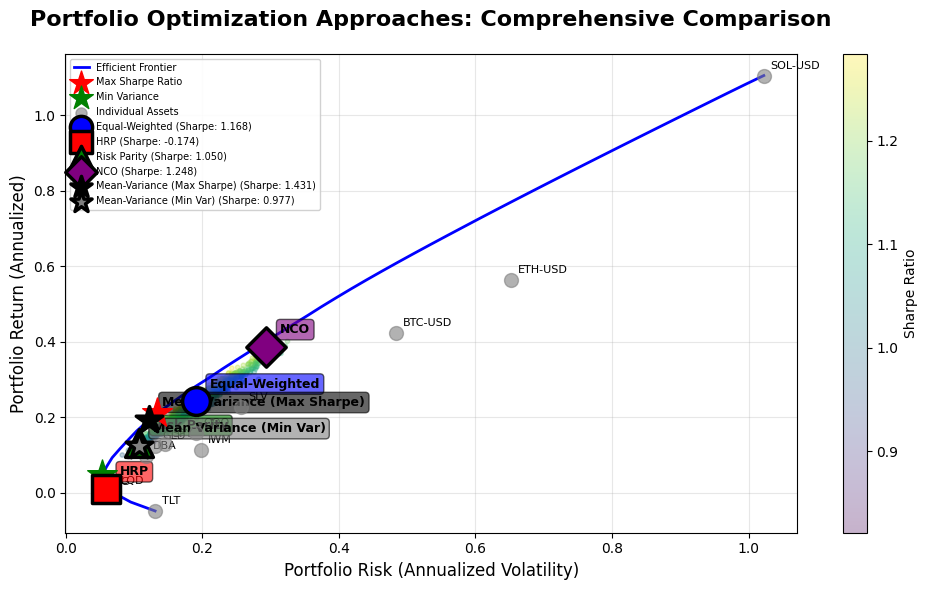


PORTFOLIO OPTIMIZATION APPROACHES: SUMMARY COMPARISON
                  Approach Return (Annualized) Volatility (Annualized) Sharpe Ratio
            Equal-Weighted              24.21%                  19.02%        1.168
                       HRP               0.98%                   5.85%       -0.174
               Risk Parity              13.29%                  10.75%        1.050
                       NCO              38.62%                  29.35%        1.248
Mean-Variance (Max Sharpe)              19.32%                  12.10%        1.431
   Mean-Variance (Min Var)              12.40%                  10.65%        0.977


In [17]:
# Final Comparison: All Approaches on Efficient Frontier
fig, ax = plot_efficient_frontier(
    ret_df,
    risk_free_rate=0.02,
    num_points=50,
    show_random=True,
    num_random=1000
)

# Calculate metrics for all approaches
# Equal-Weighted
equal_ret_annual = equal_pf_return * 252
equal_vol_annual = equal_pf_vol * np.sqrt(252)

# HRP
hrp_ret_annual, hrp_vol_annual, hrp_sharpe_annual = hrp.portfolio_performance(risk_free_rate=0.02)

# Risk Parity
rp_ret_annual, rp_vol_annual, rp_sharpe_annual = rp.portfolio_performance(risk_free_rate=0.02)

# NCO
nco_ret_annual, nco_vol_annual, nco_sharpe_annual = nco.portfolio_performance(risk_free_rate=0.02)

# Mean-Variance
mv_ret_annual = mv_return
mv_vol_annual = mv_vol
mv_sharpe_annual = mv_sharpe

mv_minvar_ret_annual = mv_minvar_return
mv_minvar_vol_annual = mv_minvar_vol
mv_minvar_sharpe_annual = mv_minvar_sharpe

# Plot all approaches with distinct markers and colors
approaches = [
    ('Equal-Weighted', equal_vol_annual, equal_ret_annual, equal_pf_sharpe, 'blue', 'o'),
    ('HRP', hrp_vol_annual, hrp_ret_annual, hrp_sharpe_annual, 'red', 's'),
    ('Risk Parity', rp_vol_annual, rp_ret_annual, rp_sharpe_annual, 'green', '^'),
    ('NCO', nco_vol_annual, nco_ret_annual, nco_sharpe_annual, 'purple', 'D'),
    ('Mean-Variance (Max Sharpe)', mv_vol_annual, mv_ret_annual, mv_sharpe_annual, 'black', '*'),
    ('Mean-Variance (Min Var)', mv_minvar_vol_annual, mv_minvar_ret_annual, mv_minvar_sharpe_annual, 'gray', '*')
]

for name, vol, ret, sharpe, color, marker in approaches:
    ax.scatter(vol, ret, marker=marker, s=400,
               color=color, edgecolors='black', linewidth=2.5,
               label=f'{name} (Sharpe: {sharpe:.3f})', zorder=7)
    
    # Add annotation
    ax.annotate(name, (vol, ret),
               xytext=(10, 10), textcoords='offset points', 
               fontsize=9, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.6, edgecolor='black'))

ax.set_title('Portfolio Optimization Approaches: Comprehensive Comparison', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Portfolio Risk (Annualized Volatility)', fontsize=12)
ax.set_ylabel('Portfolio Return (Annualized)', fontsize=12)
ax.legend(loc='best', fontsize=7, framealpha=0.9, markerscale=0.8, handlelength=1.5, columnspacing=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("PORTFOLIO OPTIMIZATION APPROACHES: SUMMARY COMPARISON")
print("="*80)
summary_df = pd.DataFrame({
    'Approach': [name for name, _, _, _, _, _ in approaches],
    'Return (Annualized)': [f"{ret:.2%}" for _, _, ret, _, _, _ in approaches],
    'Volatility (Annualized)': [f"{vol:.2%}" for _, vol, _, _, _, _ in approaches],
    'Sharpe Ratio': [f"{sharpe:.3f}" for _, _, _, sharpe, _, _ in approaches]
})
print(summary_df.to_string(index=False))
print("="*80)


### Comprehensive Risk-Return Analysis Table

**Key Portfolio Allocation Metrics:**
- **Risk-Adjusted Returns**: Sharpe Ratio (return per unit of risk)
- **Volatility**: Annualized portfolio volatility (risk measure)
- **Information Ratio**: Risk-adjusted return relative to benchmark
- **Maximum Drawdown**: Largest peak-to-trough decline
- **Out-of-Sample Volatility Forecast Accuracy**: How well the portfolio's risk is predicted

**Primary Focus**: Portfolio allocation is about proper risk management, not just returns. We measure:
1. **Information captured** via asset allocation (diversification benefits)
2. **Risk per unit of return** (Sharpe ratio, information ratio)
3. **Out-of-sample volatility forecasting accuracy** (how well we predict portfolio risk)


In [18]:
# Comprehensive Risk-Return Analysis Table
# Focus on risk-adjusted metrics and volatility forecasting
tickers = [

    # crypto
    "BTC-USD",
    "ETH-USD",
    "SOL-USD",
    # Stocks (Equity Asset Class)
    "SPY",    # S&P 500 - Large cap US stocks
    "QQQ",    # Nasdaq 100 - Tech-heavy US stocks
    "IWM",    # Russell 2000 - Small cap US stocks
    
    # Bonds (Fixed Income Asset Class)
    "TLT",    # 20+ Year Treasury - Long-term government bonds
    "AGG",    # Aggregate Bond - Total bond market
    "LQD",    # Corporate Bond - Investment grade corporate bonds
    
    # Commodities (Alternative Asset Class)
    "GLD",    # Gold - Precious metals
    "SLV",    # Silver - Precious metals
    "DBA",    # Agriculture - Commodities basket
]

print("Portfolio Asset Classes:")
print("=" * 60)
print("Crypto (U.S. Crypto Strategic Reserve):     BTC-USD, ETH-USD, SOL-USD")
print("Stocks (Equity):                            SPY, QQQ, IWM")
print("Bonds (Fixed Income):                       TLT, AGG, LQD")
print("Commodities:                                GLD, SLV, DBA")
print("=" * 60)

df = yf.download(tickers, start='2010-01-01')
ret_df = df.xs("Close", axis=1, level='Price').pct_change().dropna()

from portfolios.utilities.portfolio_utilties import (
    portfolio_expected_return,
    portfolio_volatility,
    sharpe_ratio_traditional,
    max_drawdown
)

# Calculate metrics for all methods
def calculate_portfolio_metrics(weights, returns_df, method_name):
    """Calculate comprehensive portfolio metrics"""
    # Portfolio returns
    port_returns = weighted_portfolio_returns(returns_df, weights)
    
    # Annualized metrics
    annual_return = portfolio_expected_return(returns_df, weights) * 252
    annual_vol = portfolio_volatility(returns_df, weights) * np.sqrt(252)
    sharpe = (annual_return - 0.02) / annual_vol if annual_vol > 0 else 0
    
    # Maximum drawdown
    cumulative = (1 + port_returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    # Information ratio (vs equal-weighted benchmark)
    benchmark_returns = weighted_portfolio_returns(returns_df, equal_weights)
    excess_returns = port_returns - benchmark_returns
    tracking_error = excess_returns.std() * np.sqrt(252)
    info_ratio = (annual_return - (portfolio_expected_return(returns_df, equal_weights) * 252)) / tracking_error if tracking_error > 0 else 0
    
    return {
        'Method': method_name,
        'Return (Annualized)': annual_return,
        'Volatility (Annualized)': annual_vol,
        'Sharpe Ratio': sharpe,
        'Information Ratio': info_ratio,
        'Max Drawdown': max_dd,
        'Return/Risk Ratio': annual_return / annual_vol if annual_vol > 0 else 0
    }

# Collect all basic methods (no leveraged or market-neutral here)
# Note: Leveraged and market-neutral portfolios are shown in their respective sections
all_methods = [
    (equal_weights, 'Equal Weighted'),
    (hrp_weights, 'HRP'),
    (re_hrp_weights, 'RE-HRP'),
    (rp_weights, 'Risk Parity'),
    (nco_weights, 'NCO'),
    (mv_weights, 'Mean-Variance (Max Sharpe)'),
    (mv_minvar_weights, 'Mean-Variance (Min Var)')
]

# Calculate metrics for all methods
metrics_list = []
for weights, method_name in all_methods:
    metrics = calculate_portfolio_metrics(weights, ret_df, method_name)
    metrics_list.append(metrics)

# Create DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Format for display
display_df = metrics_df.copy()
display_df['Return (Annualized)'] = display_df['Return (Annualized)'].apply(lambda x: f"{x:.4%}")
display_df['Volatility (Annualized)'] = display_df['Volatility (Annualized)'].apply(lambda x: f"{x:.4%}")
display_df['Sharpe Ratio'] = display_df['Sharpe Ratio'].apply(lambda x: f"{x:.4f}")
display_df['Information Ratio'] = display_df['Information Ratio'].apply(lambda x: f"{x:.4f}")
display_df['Max Drawdown'] = display_df['Max Drawdown'].apply(lambda x: f"{x:.4%}")
display_df['Return/Risk Ratio'] = display_df['Return/Risk Ratio'].apply(lambda x: f"{x:.4f}")

# Display using tabulate
print("=" * 120)
print("COMPREHENSIVE RISK-RETURN ANALYSIS: ALL PORTFOLIO METHODS")
print("=" * 120)
print("\nPrimary Metrics: Risk-Adjusted Returns, Volatility, and Information Capture")
print("=" * 120)
print(tabulate(display_df, headers='keys', tablefmt='grid', showindex=False))
print("=" * 120)

# Highlight key insights
print("\nKEY INSIGHTS:")
print("-" * 120)
print("1. Sharpe Ratio: Measures return per unit of risk (higher is better)")
print("2. Information Ratio: Measures risk-adjusted return vs equal-weighted benchmark")
print("3. Volatility: Primary risk metric - must be considered alongside returns")
print("4. Max Drawdown: Largest peak-to-trough decline (downside risk)")
print("5. Return/Risk Ratio: Simple risk-adjusted return measure")
print("=" * 120)


Portfolio Asset Classes:
Crypto (U.S. Crypto Strategic Reserve):     BTC-USD, ETH-USD, SOL-USD
Stocks (Equity):                            SPY, QQQ, IWM
Bonds (Fixed Income):                       TLT, AGG, LQD
Commodities:                                GLD, SLV, DBA


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_41916/2681920448.py:33: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start='2010-01-01')
[*********************100%***********************]  12 of 12 completed

COMPREHENSIVE RISK-RETURN ANALYSIS: ALL PORTFOLIO METHODS

Primary Metrics: Risk-Adjusted Returns, Volatility, and Information Capture
+----------------------------+-----------------------+---------------------------+----------------+---------------------+----------------+---------------------+
| Method                     | Return (Annualized)   | Volatility (Annualized)   |   Sharpe Ratio |   Information Ratio | Max Drawdown   |   Return/Risk Ratio |
+============================+=======================+===========================+================+=====================+================+=====================+
| Equal Weighted             | 24.2078%              | 19.0194%                  |         1.1676 |              0      | -42.7915%      |              1.2728 |
+----------------------------+-----------------------+---------------------------+----------------+---------------------+----------------+---------------------+
| HRP                        | 0.9818%               | 5.850


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_41916/2681920448.py:34: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_df = df.xs("Close", axis=1, level='Price').pct_change().dropna()


## Out-of-Sample Volatility Forecasting and Accuracy

**Primary Focus**: Portfolio allocation success is measured by how accurately we can forecast portfolio volatility out-of-sample. This is the key metric for risk management.

**Why Out-of-Sample Volatility Matters:**
- In-sample volatility can be misleading (overfitting)
- Out-of-sample volatility reflects true portfolio risk
- Accurate volatility forecasts enable proper risk budgeting
- Better volatility forecasts → better risk-adjusted returns

**Metrics:**
- **Forecasted Volatility**: Predicted portfolio volatility using in-sample data
- **Realized Volatility**: Actual portfolio volatility in out-of-sample period
- **Forecast Error**: Difference between forecasted and realized volatility
- **Forecast Accuracy**: How well we predict portfolio risk (lower error = better)


In [19]:
# Out-of-Sample Volatility Forecasting and Accuracy Analysis
# Split data into training (in-sample) and testing (out-of-sample) periods

# Use 70% for training, 30% for testing
split_idx = int(len(ret_df) * 0.7)
train_returns = ret_df.iloc[:split_idx]
test_returns = ret_df.iloc[split_idx:]

print("Out-of-Sample Volatility Forecasting Analysis")
print("=" * 100)
print(f"Training Period: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} days)")
print(f"Testing Period: {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} days)")
print("=" * 100)

def calculate_volatility_forecast_accuracy(weights, train_returns, test_returns, method_name):
    """
    Calculate in-sample forecasted volatility vs out-of-sample realized volatility
    """
    # In-sample: Forecast volatility using training data
    forecasted_vol = portfolio_volatility(train_returns, weights) * np.sqrt(252)
    
    # Out-of-sample: Realized volatility using test data
    test_portfolio_returns = weighted_portfolio_returns(test_returns, weights)
    realized_vol = test_portfolio_returns.std() * np.sqrt(252)
    
    # Forecast error and accuracy
    forecast_error = abs(forecasted_vol - realized_vol)
    forecast_error_pct = (forecast_error / realized_vol * 100) if realized_vol > 0 else 0
    forecast_accuracy = 1 - (forecast_error / realized_vol) if realized_vol > 0 else 0
    
    # In-sample realized volatility (for comparison)
    train_portfolio_returns = weighted_portfolio_returns(train_returns, weights)
    in_sample_realized_vol = train_portfolio_returns.std() * np.sqrt(252)
    
    return {
        'Method': method_name,
        'Forecasted Vol (In-Sample)': forecasted_vol,
        'Realized Vol (Out-of-Sample)': realized_vol,
        'Realized Vol (In-Sample)': in_sample_realized_vol,
        'Forecast Error (Abs)': forecast_error,
        'Forecast Error (%)': forecast_error_pct,
        'Forecast Accuracy': forecast_accuracy,
        'Volatility Ratio (Out/In)': realized_vol / forecasted_vol if forecasted_vol > 0 else 0
    }

# Calculate volatility forecasts for all methods
vol_forecast_list = []
for weights, method_name in all_methods:
    # Fit on training data
    if 'HRP' in method_name and '(1.5x)' in method_name:
        # For leveraged HRP, fit base model then scale
        temp_hrp = HierarchicalRiskParity()
        temp_hrp.fit(train_returns)
        weights_train = temp_hrp.predict() * 1.5
    elif 'NCO' in method_name and '(1.5x)' in method_name:
        # For leveraged NCO, fit base model then scale
        temp_nco = NestedClusteredOptimization()
        temp_nco.fit(train_returns)
        weights_train = temp_nco.predict() * 1.5
    elif 'Risk Parity' in method_name and '(1.5x)' in method_name:
        temp_rp = RiskParity(leverage=1.5)
        temp_rp.fit(train_returns)
        weights_train = temp_rp.predict()
    elif 'Market-Neutral' in method_name:
        temp_rp = RiskParity(allow_shorts=True, leverage=0.0)
        temp_rp.fit(train_returns)
        weights_train = temp_rp.predict()
    elif 'HRP' in method_name:
        temp_hrp = HierarchicalRiskParity()
        temp_hrp.fit(train_returns)
        weights_train = temp_hrp.predict()
    elif 'Risk Parity' in method_name:
        temp_rp = RiskParity()
        temp_rp.fit(train_returns)
        weights_train = temp_rp.predict()
    elif 'NCO' in method_name:
        temp_nco = NestedClusteredOptimization()
        temp_nco.fit(train_returns)
        weights_train = temp_nco.predict()
    elif 'Mean-Variance' in method_name:
        # Recalculate MV on training data
        train_exp_returns = train_returns.mean().values
        train_cov = train_returns.cov().values
        if 'Max Sharpe' in method_name:
            def neg_sharpe(w):
                ret = train_exp_returns.T @ w
                vol = np.sqrt(w.T @ train_cov @ w)
                return -(ret - 0.02/252) / vol if vol > 0 else 1e10
            result = minimize(neg_sharpe, np.ones(len(train_returns.columns))/len(train_returns.columns),
                            method='SLSQP', bounds=tuple((0,1) for _ in range(len(train_returns.columns))),
                            constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}))
            weights_train = result.x
        else:  # Min Var
            def port_var(w):
                return w.T @ train_cov @ w
            result = minimize(port_var, np.ones(len(train_returns.columns))/len(train_returns.columns),
                            method='SLSQP', bounds=tuple((0,1) for _ in range(len(train_returns.columns))),
                            constraints=({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}))
            weights_train = result.x
    else:  # Equal weighted
        weights_train = np.ones(len(train_returns.columns)) / len(train_returns.columns)
    
    metrics = calculate_volatility_forecast_accuracy(weights_train, train_returns, test_returns, method_name)
    vol_forecast_list.append(metrics)

# Create DataFrame
vol_forecast_df = pd.DataFrame(vol_forecast_list)

# Format for display
display_vol_df = vol_forecast_df.copy()
display_vol_df['Forecasted Vol (In-Sample)'] = display_vol_df['Forecasted Vol (In-Sample)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Realized Vol (Out-of-Sample)'] = display_vol_df['Realized Vol (Out-of-Sample)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Realized Vol (In-Sample)'] = display_vol_df['Realized Vol (In-Sample)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Forecast Error (Abs)'] = display_vol_df['Forecast Error (Abs)'].apply(lambda x: f"{x:.4%}")
display_vol_df['Forecast Error (%)'] = display_vol_df['Forecast Error (%)'].apply(lambda x: f"{x:.2f}%")
display_vol_df['Forecast Accuracy'] = display_vol_df['Forecast Accuracy'].apply(lambda x: f"{x:.4f}")
display_vol_df['Volatility Ratio (Out/In)'] = display_vol_df['Volatility Ratio (Out/In)'].apply(lambda x: f"{x:.4f}")

# Display using tabulate
print("\n" + "=" * 120)
print("OUT-OF-SAMPLE VOLATILITY FORECASTING ACCURACY")
print("=" * 120)
print("\nPrimary Metric: How accurately do we forecast portfolio volatility?")
print("Lower Forecast Error = Better Risk Management")
print("=" * 120)
print(tabulate(display_vol_df, headers='keys', tablefmt='grid', showindex=False))
print("=" * 120)

# Rank by forecast accuracy
print("\nRANKING BY VOLATILITY FORECAST ACCURACY (Best to Worst):")
print("-" * 120)
ranked = vol_forecast_df.sort_values('Forecast Accuracy', ascending=False)
for i, (idx, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {row['Method']:30s} - Accuracy: {row['Forecast Accuracy']:.4f}, Error: {row['Forecast Error (%)']:.2f}%")
print("=" * 120)


Out-of-Sample Volatility Forecasting Analysis
Training Period: 2020-04-11 to 2024-04-10 (1461 days)
Testing Period: 2024-04-11 to 2025-12-28 (627 days)

OUT-OF-SAMPLE VOLATILITY FORECASTING ACCURACY

Primary Metric: How accurately do we forecast portfolio volatility?
Lower Forecast Error = Better Risk Management
+----------------------------+------------------------------+--------------------------------+----------------------------+------------------------+----------------------+---------------------+-----------------------------+
| Method                     | Forecasted Vol (In-Sample)   | Realized Vol (Out-of-Sample)   | Realized Vol (In-Sample)   | Forecast Error (Abs)   | Forecast Error (%)   |   Forecast Accuracy |   Volatility Ratio (Out/In) |
+============================+==============================+================================+============================+========================+======================+=====================+=============================+
| Equal Weight

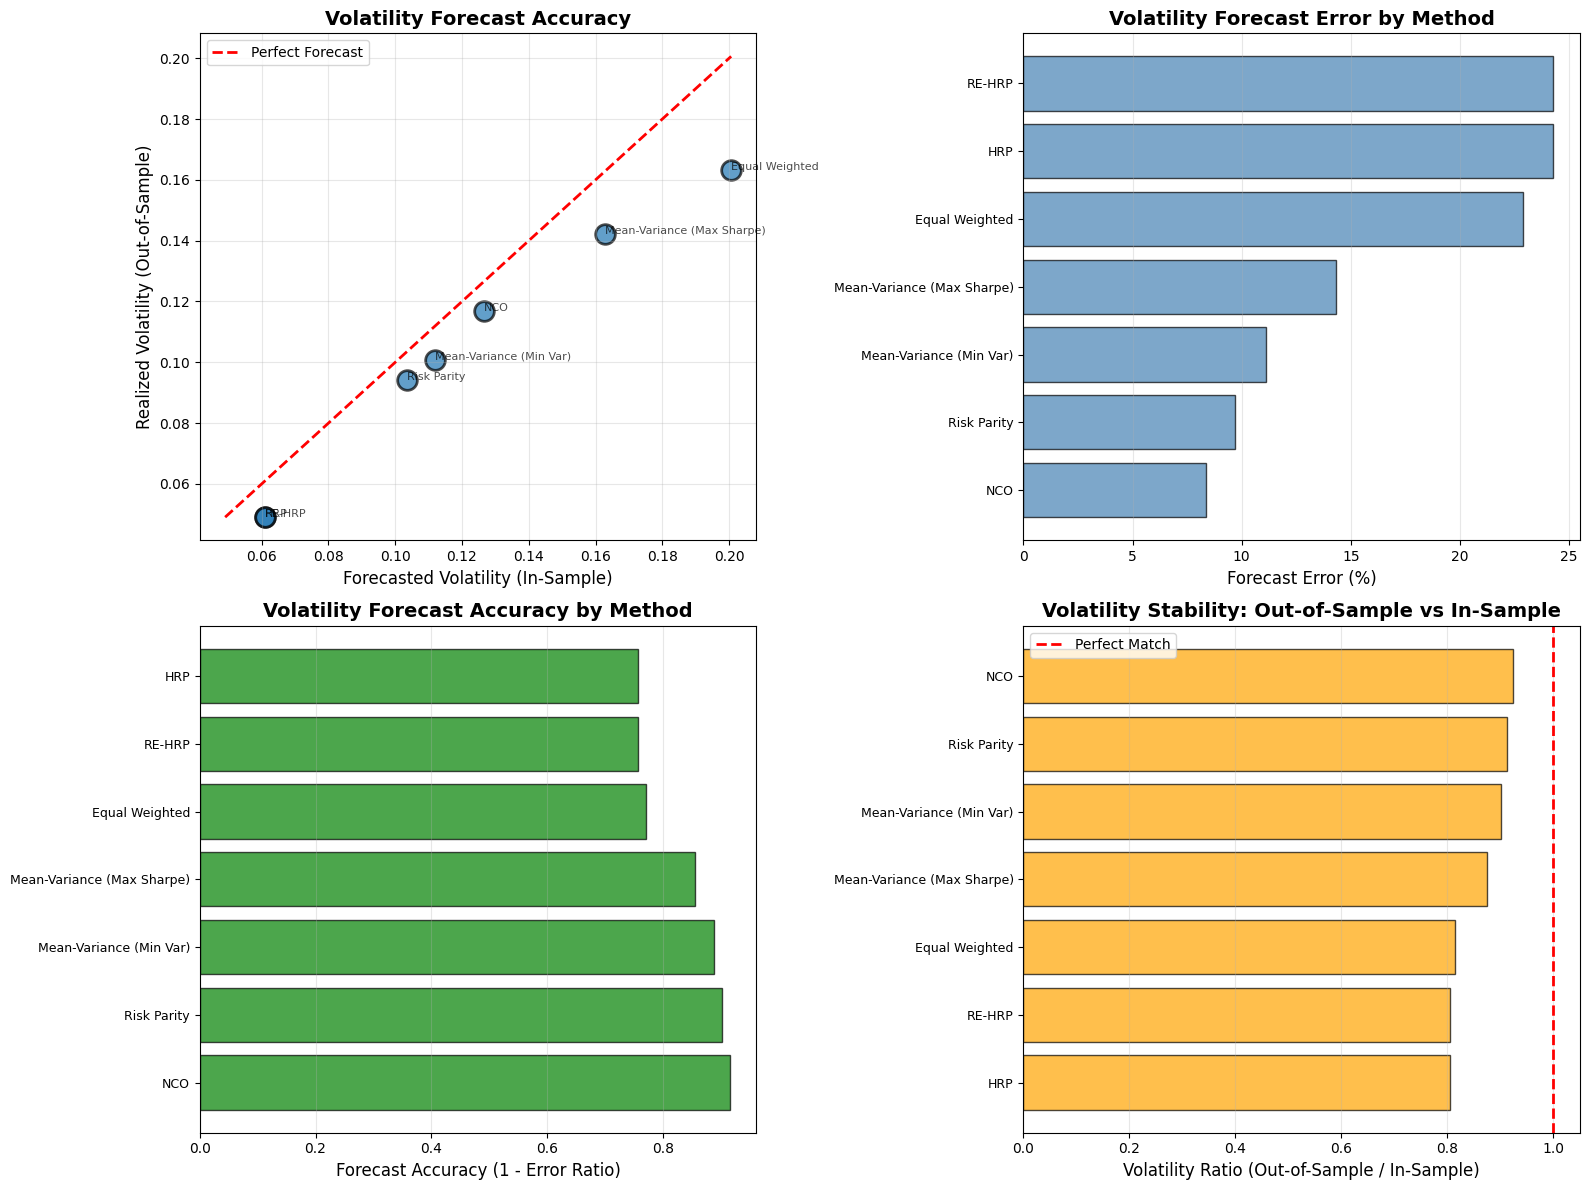


KEY INSIGHTS: OUT-OF-SAMPLE VOLATILITY FORECASTING
1. Lower Forecast Error = Better Risk Management
2. Forecast Accuracy close to 1.0 = Accurate volatility predictions
3. Volatility Ratio close to 1.0 = Stable risk profile across time periods
4. Methods with better forecast accuracy provide more reliable risk estimates


In [20]:
import matplotlib.pyplot as plt
# Visualize Out-of-Sample Volatility Forecast Accuracy
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Forecasted vs Realized Volatility
ax1 = axes[0, 0]
ax1.scatter(vol_forecast_df['Forecasted Vol (In-Sample)'], 
           vol_forecast_df['Realized Vol (Out-of-Sample)'],
           s=200, alpha=0.7, edgecolors='black', linewidth=2)
# Perfect forecast line
min_vol = min(vol_forecast_df['Forecasted Vol (In-Sample)'].min(), 
              vol_forecast_df['Realized Vol (Out-of-Sample)'].min())
max_vol = max(vol_forecast_df['Forecasted Vol (In-Sample)'].max(), 
              vol_forecast_df['Realized Vol (Out-of-Sample)'].max())
ax1.plot([min_vol, max_vol], [min_vol, max_vol], 'r--', linewidth=2, label='Perfect Forecast')
ax1.set_xlabel('Forecasted Volatility (In-Sample)', fontsize=12)
ax1.set_ylabel('Realized Volatility (Out-of-Sample)', fontsize=12)
ax1.set_title('Volatility Forecast Accuracy', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Add method labels
for idx, row in vol_forecast_df.iterrows():
    ax1.annotate(row['Method'], 
                (row['Forecasted Vol (In-Sample)'], row['Realized Vol (Out-of-Sample)']),
                fontsize=8, alpha=0.7)

# Plot 2: Forecast Error by Method
ax2 = axes[0, 1]
sorted_df = vol_forecast_df.sort_values('Forecast Error (%)')
ax2.barh(range(len(sorted_df)), sorted_df['Forecast Error (%)'], 
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(sorted_df)))
ax2.set_yticklabels(sorted_df['Method'], fontsize=9)
ax2.set_xlabel('Forecast Error (%)', fontsize=12)
ax2.set_title('Volatility Forecast Error by Method', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Forecast Accuracy by Method
ax3 = axes[1, 0]
sorted_df_acc = vol_forecast_df.sort_values('Forecast Accuracy', ascending=False)
ax3.barh(range(len(sorted_df_acc)), sorted_df_acc['Forecast Accuracy'], 
        color='green', alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(sorted_df_acc)))
ax3.set_yticklabels(sorted_df_acc['Method'], fontsize=9)
ax3.set_xlabel('Forecast Accuracy (1 - Error Ratio)', fontsize=12)
ax3.set_title('Volatility Forecast Accuracy by Method', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Plot 4: Volatility Ratio (Out-of-Sample / In-Sample)
ax4 = axes[1, 1]
sorted_df_ratio = vol_forecast_df.sort_values('Volatility Ratio (Out/In)')
ax4.barh(range(len(sorted_df_ratio)), sorted_df_ratio['Volatility Ratio (Out/In)'], 
        color='orange', alpha=0.7, edgecolor='black')
ax4.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Perfect Match')
ax4.set_yticks(range(len(sorted_df_ratio)))
ax4.set_yticklabels(sorted_df_ratio['Method'], fontsize=9)
ax4.set_xlabel('Volatility Ratio (Out-of-Sample / In-Sample)', fontsize=12)
ax4.set_title('Volatility Stability: Out-of-Sample vs In-Sample', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "=" * 120)
print("KEY INSIGHTS: OUT-OF-SAMPLE VOLATILITY FORECASTING")
print("=" * 120)
print("1. Lower Forecast Error = Better Risk Management")
print("2. Forecast Accuracy close to 1.0 = Accurate volatility predictions")
print("3. Volatility Ratio close to 1.0 = Stable risk profile across time periods")
print("4. Methods with better forecast accuracy provide more reliable risk estimates")
print("=" * 120)


In [21]:
# Quick calculation of Equal-Weighted Portfolio metrics for comparison
# This is needed since some work was moved to portfolio_basic.ipynb

from portfolios.utilities.portfolio_utilties import (
    portfolio_expected_return,
    portfolio_volatility,
    portfolio_sharpe_ratio
)

# Create equal weights (1/n for each asset)
n_assets = len(ret_df.columns)
equal_weights = np.ones(n_assets) / n_assets

# Calculate equal-weighted portfolio metrics (daily)
equal_pf_return = portfolio_expected_return(ret_df, equal_weights)
equal_pf_vol = portfolio_volatility(ret_df, equal_weights)
equal_pf_sharpe = portfolio_sharpe_ratio(ret_df, equal_weights)

print("Equal-Weighted Portfolio Metrics (for comparison):")
print(f"Expected Return (daily): {equal_pf_return:.6f}")
print(f"Expected Return (annualized): {equal_pf_return * 252:.4%}")
print(f"Volatility (daily): {equal_pf_vol:.6f}")
print(f"Volatility (annualized): {equal_pf_vol * np.sqrt(252):.4%}")
print(f"Sharpe Ratio (annualized): {equal_pf_sharpe:.4f}")


Equal-Weighted Portfolio Metrics (for comparison):
Expected Return (daily): 0.000961
Expected Return (annualized): 24.2078%
Volatility (daily): 0.011981
Volatility (annualized): 19.0194%
Sharpe Ratio (annualized): 1.1676


In [22]:
# Compare weights across methods
weights_comparison = pd.DataFrame({
    'Asset': ret_df.columns,
    'Equal-Weighted': equal_weights,
    'HRP': hrp_weights,
    'RE-HRP': re_hrp_weights,
    'Risk Parity': rp_weights,
    'NCO': nco_weights
})

weights_comparison = weights_comparison.set_index('Asset')
weights_comparison = weights_comparison * 100  # Convert to percentages

print("Portfolio Weights Comparison (%):")
print(weights_comparison.round(2))


Portfolio Weights Comparison (%):
         Equal-Weighted    HRP  RE-HRP  Risk Parity    NCO
Asset                                                     
AGG                8.33  55.12    9.00         9.99   0.00
BTC-USD            8.33   0.04    9.12         4.95   0.00
DBA                8.33   6.06    7.29        10.08   0.00
ETH-USD            8.33   0.03   16.49         1.52   0.00
GLD                8.33   3.32    6.56        10.31   0.00
IWM                8.33   0.64    5.31        10.18  18.14
LQD                8.33  20.48    8.10        10.13   0.00
QQQ                8.33   0.38    4.78        10.18   0.00
SLV                8.33   0.68    5.90        10.39  61.34
SOL-USD            8.33   0.01   15.69         1.82  20.51
SPY                8.33   0.39    1.74        10.25   0.00
TLT                8.33  12.87   10.00        10.20   0.00


In [30]:
# Monte Carlo Simulation: Generate random weight patterns for value-weighted approaches
print("="*80)
print("MONTE CARLO SIMULATION: Value-Weighted Approaches")
print("="*80)

np.random.seed(42)  # For reproducibility
n_mcs_simulations = 100
n_assets = len(train_returns.columns)

# Generate random weight patterns
mcs_weights_list = []
mcs_train_metrics = []

for i in range(n_mcs_simulations):
    # Generate random weights (Dirichlet distribution ensures they sum to 1)
    random_weights = np.random.dirichlet(np.ones(n_assets))
    
    # Calculate portfolio metrics on training data
    train_return = portfolio_expected_return(train_returns, random_weights)
    train_vol = portfolio_volatility(train_returns, random_weights)
    train_sharpe = portfolio_sharpe_ratio(train_returns, random_weights, risk_free_rate=0.02)
    
    mcs_weights_list.append(random_weights)
    mcs_train_metrics.append({
        'return': train_return * 252,  # Annualized
        'volatility': train_vol * np.sqrt(252),  # Annualized
        'sharpe': train_sharpe
    })

# Convert to DataFrame for analysis
mcs_train_df = pd.DataFrame(mcs_train_metrics)

print(f"Generated {n_mcs_simulations} random weight patterns")
print(f"\nTraining Metrics Summary (MCS):")
print(f"  Return (annualized): {mcs_train_df['return'].mean():.2%} ± {mcs_train_df['return'].std():.2%}")
print(f"  Volatility (annualized): {mcs_train_df['volatility'].mean():.2%} ± {mcs_train_df['volatility'].std():.2%}")
print(f"  Sharpe Ratio: {mcs_train_df['sharpe'].mean():.3f} ± {mcs_train_df['sharpe'].std():.3f}")

# Select best MCS portfolio based on Sharpe ratio (for comparison)
best_mcs_idx = mcs_train_df['sharpe'].idxmax()
best_mcs_weights = mcs_weights_list[best_mcs_idx]
print(f"\nBest MCS Portfolio (by Sharpe ratio):")
print(f"  Return: {mcs_train_df.loc[best_mcs_idx, 'return']:.2%}")
print(f"  Volatility: {mcs_train_df.loc[best_mcs_idx, 'volatility']:.2%}")
print(f"  Sharpe: {mcs_train_df.loc[best_mcs_idx, 'sharpe']:.3f}")

print("="*80)


MONTE CARLO SIMULATION: Value-Weighted Approaches
Generated 100 random weight patterns

Training Metrics Summary (MCS):
  Return (annualized): 30.39% ± 13.52%
  Volatility (annualized): 22.48% ± 8.83%
  Sharpe Ratio: 1.228 ± 0.143

Best MCS Portfolio (by Sharpe ratio):
  Return: 55.25%
  Volatility: 37.43%
  Sharpe: 1.423
